In [1]:
import sys
import os

from statsmodels.stats.multitest import multipletests as mt
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import json
from limix_modified.plot._manhattan import manhattan
from limix_modified.plot._qqplot import qqplot

In [ ]:
annot= pd.read_csv("/sc/home/bibiana.horn/results/gpr/thaliana_snp_annotation.csv", sep=',', index_col=0)
annot.columns = ['chrom', 'pos']
print(annot)

        chrom       pos
0           1       657
1           1      3102
2           1      4648
3           1      6063
4           1      6449
...       ...       ...
173215      5  26972753
173216      5  26973018
173217      5  26973441
173218      5  26973598
173219      5  26974904

[173220 rows x 2 columns]


In [4]:
#uid = "dd636f33-b795-483a-9c9c-15146fe67cdf"
#file_dir = os.path.join("/sc/home/bibiana.horn/projects/multi_task_gpr/simulation_results/torchLIMIX_resc_rank4_tasks4/eta0.30/rep0000")
file_dir = os.path.join("/sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/run_numpylimix/simulation_results_defaultC0/eta0.60/rep0004")
file_path = os.path.join(file_dir, "log_likelihoods.csv")
# Load the data
if os.path.isfile(file_path):
    print(f"Loading log-likelihoods from {file_path}.")
    log_likelihoods = pd.read_csv(file_path)
else:
    raise FileNotFoundError(f"Likelihood file does not exist: {file_path}.")

# Extract relevant columns
lml0 = log_likelihoods['lml0'].values
lml1 = log_likelihoods['lml1'].values
lml2 = log_likelihoods['lml2'].values
llr10 = log_likelihoods['lrt10'].values
llr20 = log_likelihoods['lrt20'].values
llr21 = log_likelihoods['lrt21'].values
df10 = log_likelihoods['df10'].values
df20 = log_likelihoods['df20'].values
df21 = log_likelihoods['df21'].values

print(lml0)
#LRT_permuted = LRT_permuted[LRT_permuted <= upper_bound]
# Check distribution of LRT values
plt.hist(llr10, bins=50, density=True, alpha=0.7, color='blue', label='LRT 10')
plt.hist(llr20, bins=50, density=True, alpha=0.7, color='green', label='LRT 20')
plt.hist(llr21, bins=50, density=True, alpha=0.7, color='yellow', label='LRT 12')
plt.xlabel('Likelihood Ratio Test Statistics [a.u.]', fontsize=15)
plt.ylabel('Density [a.u.]', fontsize=15)

# Increase tick label size
plt.tick_params(axis='both', which='major', labelsize=13)  # Adjust 'labelsize' to your preferred size

# Add legend and show plot
plt.legend(fontsize=12)  # Optionally increase legend font size
plt.show()

Loading log-likelihoods from /sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/run_numpylimix/simulation_results_defaultC0/eta0.60/rep0004/log_likelihoods.csv.


KeyError: 'lrt10'

In [11]:
#Correct the alpha level for multiple tests
file_path = os.path.join("/sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/run_numpylimix/simulation_results_defaultC0/eta0.60/rep0004/log_likelihoods.csv")
if os.path.isfile(file_path):
    print(f"Loading log-likelihoods from {file_path}.")
    log_likelihoods = pd.read_csv(file_path)
else:
    raise FileNotFoundError(f"Likelihood file does not exist: {file_path}.")


FileNotFoundError: Likelihood file does not exist: /sc/home/bibiana.horn/projects/LIMIX_modified/limix_modified/run_numpylimix/simulation_results_defaultC0/eta0.60/rep0004/log_likelihoods.csv.

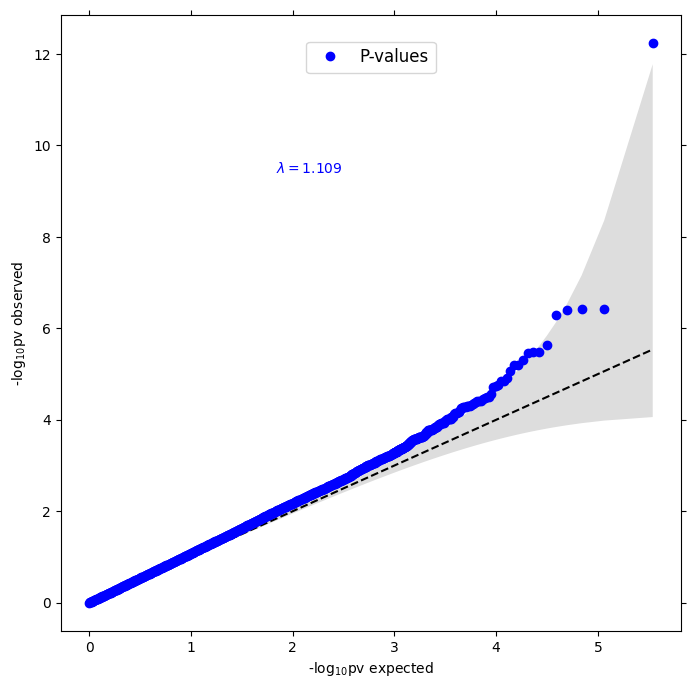

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(log_likelihoods['pv10'].values, alpha=0.05, method='bonferroni')
qqplot(log_likelihoods['pv10'].values, line='s', ax=ax, label='P-values', alpha=alphacBonf, pts_kws=dict(marker='o', color='blue'))
plt.legend(
    fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.97)  # Adjust the y-coordinate
)
plt.show()

- lrt10: Omnibus test: Does the SNP affect something at all?
- lrt20: Targeted test: Is this trait affected by the SNP?
- lrt21: Differential/pleiotropy test: Is only one trait affected, or are others also affected?

In [7]:
chromosomes = annot['chrom']  # Adjust this to the actual key in your HDF5 file
positions = annot['pos'] 

result_mt_10 = pd.DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': log_likelihoods['pv10'].values
})
result_mt_20 = pd.DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': log_likelihoods['pv20'].values,
})
result_mt_21 = pd.DataFrame({
    'chrom': chromosomes,
    'pos': positions,
    'pv': log_likelihoods['pv21'].values
})
reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(log_likelihoods['pv21'].values, alpha=0.05, method='bonferroni')
print(result_mt_21)

        chrom       pos        pv
0           1       657  0.082707
1           1      3102  0.160740
2           1      4648  0.236433
3           1      6063  0.279293
4           1      6449  0.040374
...       ...       ...       ...
173215      5  26972753  0.004485
173216      5  26973018  0.017140
173217      5  26973441  0.003350
173218      5  26973598  0.012713
173219      5  26974904  0.732442

[173220 rows x 3 columns]


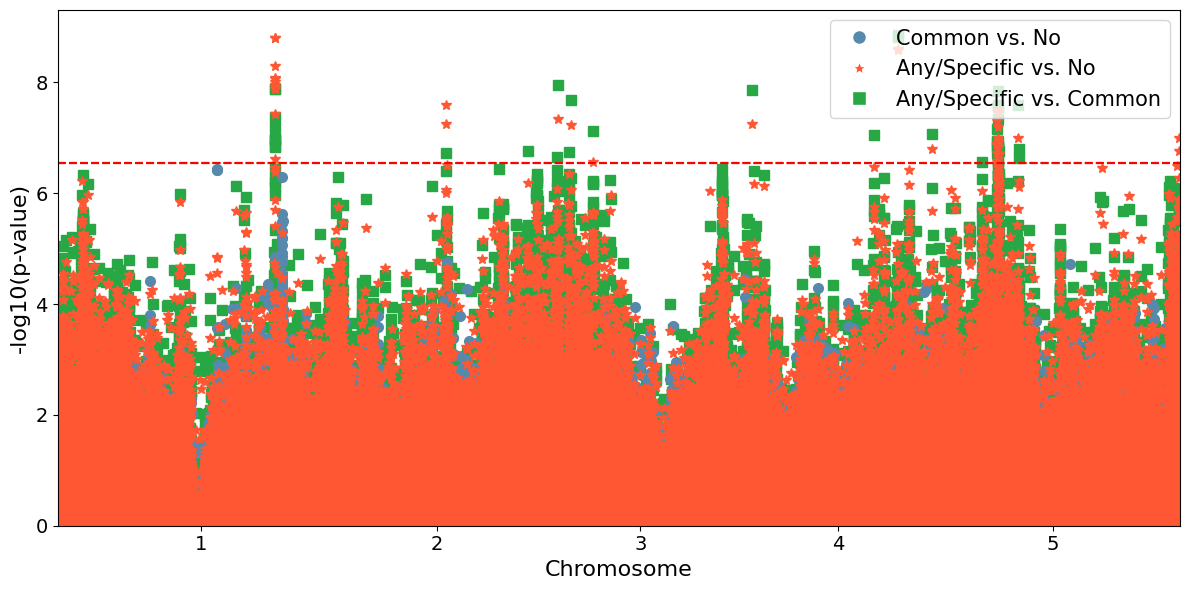

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

manhattan(result_mt_21, 
          colora="#28A745",  # Change to another different color for the third plot
          colorb="#28A745", 
          highlight_color="#28A745", 
          threshold=alphacBonf, 
          pts_kws={'marker': 's', 'markersize': 7}, 
          ax=ax)


# Plot the first Manhattan plot
manhattan(result_mt_10, 
          colora="#5689AC", 
          colorb="#5689AC", 
          highlight_color="#5689AC", 
          threshold=alphacBonf, 
          pts_kws={'marker': 'o', 'markersize': 7},  # Circle markers, 
          ax=ax)

manhattan(result_mt_20, 
          colora="#FF5733",  # Change to a different color for the second plot
          colorb="#FF5733", 
          highlight_color="#FF5733", 
          threshold=alphacBonf, 
          pts_kws={'marker': '*', 'markersize': 7}, 
          ax=ax)

# Set larger x and y labels
ax.set_xlabel("Chromosome", fontsize=16)  # Increase font size for x-axis label
ax.set_ylabel("-log10(p-value)", fontsize=16)  # Increase font size for y-axis label

ax.tick_params(axis='both', which='major', labelsize=14)  # Adjust tick label font size

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Common vs. No', markerfacecolor='#5689AC', markersize=10),
    plt.Line2D([0], [0], marker='*', color='w', label='Any/Specific vs. No', markerfacecolor='#FF5733', markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='Any/Specific vs. Common', markerfacecolor='#28A745', markersize=10)
]
ax.legend(handles=handles, loc='upper right', fontsize=15) #, title="Legend"

plt.tight_layout()
plt.show()



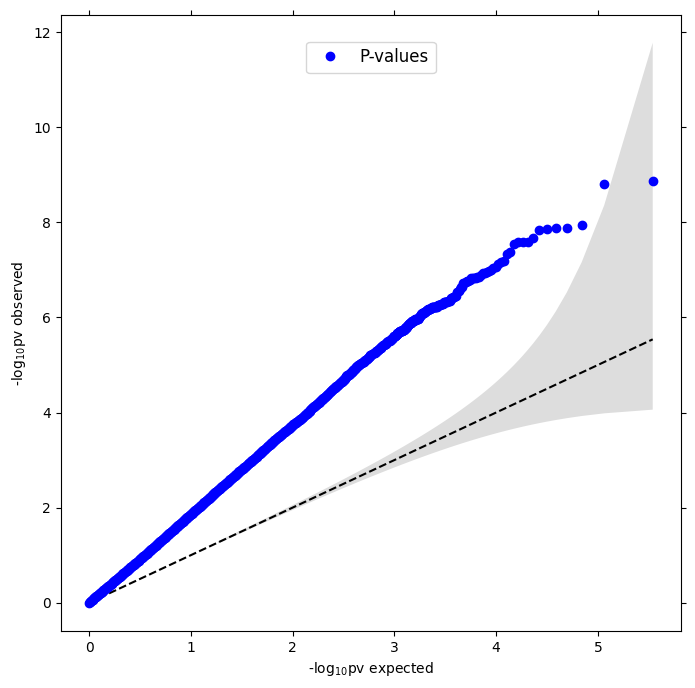

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(log_likelihoods['pv21'].values, alpha=0.05, method='bonferroni')
#qqplot(log_likelihoods['pv21'].values, line='s', ax=ax, label='P-values', alpha=alphacBonf, pts_kws=dict(marker='o', color='blue'))
qqplot(log_likelihoods['pv21'].values, 
       line=True, 
       ax=ax, 
       label='P-values',
       alpha=alphacBonf, 
       pts_kws=dict(marker='o', color='blue'),
       #lambda_in_label=True,
       show_lambda=False)
plt.legend(
    fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.97)  # Adjust the y-coordinate
)
plt.show()

In [10]:
significant_indices_21 = np.where(reject_)[0]
print("Significant SNP indices for pv21:", significant_indices_21)

Significant SNP indices for pv21: [ 31093  31096  31097  31098  31100  31101  31102  31104  31125  55345
  64928  69094  69220  70807  71209  74585 100453 123562 126530 126533
 131464 138614 141406 141412 141425 141429 141430 141651 141657 141658
 141662 141670 141672 141676 141678 141681 141685 141691 145733 145843
 145849]


In [84]:
# After calculating reject_ and alphacBonf for pv21
reject_, pvals_corrected_, alphacSidak, alphacBonf = mt(log_likelihoods['pv21'].values, alpha=0.05, method='bonferroni')
significant_indices_21 = np.where(reject_)[0]

print(f"\nNumber of significant SNPs for pv21: {len(significant_indices_21)}")
print(f"Bonferroni threshold: {alphacBonf}")
print(f"Threshold in -log10 scale: {-np.log10(alphacBonf)}")

# Check the actual p-values and -log10(p) for significant pv21 SNPs
if len(significant_indices_21) > 0:
    pv21_sig = log_likelihoods['pv21'].values[significant_indices_21]
    print(f"\nSignificant pv21 p-values: {pv21_sig}")
    print(f"Significant pv21 -log10(p): {-np.log10(pv21_sig)}")
    
    # Check if these same positions are significant in other tests
    print(f"\nAt these same positions:")
    print(f"pv10 p-values: {log_likelihoods['pv10'].values[significant_indices_21]}")
    print(f"pv20 p-values: {log_likelihoods['pv20'].values[significant_indices_21]}")


Number of significant SNPs for pv21: 0
Bonferroni threshold: 2.8865027133125506e-07
Threshold in -log10 scale: 6.539628029928346
